In [16]:
# general libraries
import numpy as np
import pandas as pd
import scipy.integrate as integrate
import scipy.special as special
from scipy.integrate import quad
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker
from IPython.display import Video

# project libraries
from lcpalib import presets as ps
from lcpalib import plotting as pl

# matplotlib setup and numpy random seed
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline
np.random.seed(311)

# Simulation of a positron-induced Muon Source (part 1)

The production of a high brillance muon beam is one of the most important challenge for the future of Particle Physics. A particularly interesting idea consists of shooting high energy positrons on a target, aiming at the production of muons by means of the process $e^+ + e^- \rightarrow \mu^+ + \mu^-$. To mimize the divergence of the resulting "muon beam", the positrons energy is chosen so that the reaction occurs close to threshold (assuming the electrons in the target to be at rest). The main goal of this project is to produce a Monte Carlo simulation of such a process.

### Authors:
Andrea Semenzato, Pietro Bernardi, Tomas Mezquita, Mariam Chokheli


### Supervisor:
Prof.Marco Zanetti

In [17]:
# set this to kPRES to switch to presentation mode and avoid re-calculation of quantities
MODE = ps.kEDIT

# constants
mu_mass=0.105658374524 #muon mass in GeV
e_mass = 0.0005109989461 # GeV
fsc=1/137. #fine structure constant
conv = 0.389379e6 #GeV^-1 to nB
E_sim=2*mu_mass + 0.005

### Point 1
Compute the process leading-order cross section, $\sigma(\theta;\sqrt{s})$, as a function of the scattering angle $\theta$ and with the center of mass energy $\sqrt{s}$ as a parameter.

### Cross section in the center of mass frame.
The process
$ e^- + e^+ \rightarrow \mu^- + \mu^+ $
is fundamental in the understanding of QED theory, and very important in high energy physics for the understanding of $e^-e^+$ colliders and more complicated processes.
<br>
Let's compute the cross-section of this process in the center of the mass frame. First, let's discuss the mass order of the fermions: as we know this process has an energy about the order of at least two times the muon mass. Also recall that $m_\mu/m_e\sim 200$, so $m_e^2<<s$, consequently, we can assume an electron massless limit, while the muon mass cannot be negligible.

Also recall that $s$ is a Mandelstam variable and corresponds to $s=(p_1+p_2)^2=(p_3+p_4)^2$.

Firstly, we need to compute the Feynmann diagram and the correspondent amplitude $\mathcal{M}$, following the Feynmann rules.
<center>
    <img src="./img/FDME.png" alt="Feynmann diagram" width="400">
</center>

$$i\mathcal{M}=\frac{ie^2}{s} [\bar{v}(p_2) \gamma^\mu u(p_1)] [\bar{u}(p_3) \gamma_\mu v(p_4)] $$

As we can see, this process can be only possible through an s-channel. The next step is to compute the summed squared amplitude over the initial polarization states:

$$|\mathcal{\bar{M}}|^2=\frac{8e^4}{s^2} [(p_1\cdot p_3)(p_2\cdot p_4)+(p_1\cdot p_4)(p_2\cdot p_3)+m_\mu^2(p_1\cdot p_2)]$$

Let's now apply the center of mass frame and energy/momentum conservation, we can express the 4-momentum of all the particles in the following way:

<center>
    <img src="./img/CoM.png" width="700">
</center>

Using that in the electron massless limit $s=(p_1+p_2)^2=2(p_1\cdot p_2)=4E^2$, we can establish the relation $E=\frac{\sqrt{s}}{2}$, and $|\vec{k}|=\sqrt{E^2-m_\mu^2}=\frac{1}{2}\sqrt{s-4m_\mu^2}$.

We can write the summed squared amplitude over the initial polarization states as a funtion of $s$ and $\theta$ variables:

$$|\mathcal{\bar{M}}|^2=16\pi^2\alpha^2\left[\left(1+\frac{4m_\mu^2}{s}\right)+\left(1-\frac{4m_\mu^2}{s}\right)\cos^2{\theta}\right]$$

We can now compute the differential cross section using the following expression: $\frac{d\sigma}{d\Omega}=\frac{1}{64\pi^2 s}\frac{|\vec{k}|}{E}|\mathcal{\bar{M}}|^2$. We get the following expression:

$$\left(\frac{d\sigma}{d\Omega}\right)_{CM}=\frac{ \alpha^2}{4 s} \sqrt{1-\frac{4m_\mu^2}{s}} \left[\left(1+\frac{4m_\mu^2}{s}\right)+\left(1-\frac{4m_\mu^2}{s}\right)\cos^2{\theta}\right]$$

Now we integrate the differential cross section in order to get the total cross section:

$$\sigma=\int_{-1}^{1} \frac{d\sigma}{d\Omega} d\Omega= \frac{4\pi \alpha^2}{3s} \sqrt{1-\frac{4m_\mu^2}{s}} \left(1+\frac{2m_\mu^2}{s}\right) $$

Let's start now with the computation and analysis of all this magnitudes:

In [4]:
#Functions
def cross_section(s=E_sim**2): #s in GeV^2
    return (4*np.pi*fsc**2)/(3*s)*np.sqrt(1-4*mu_mass**2/s)*(1+2*mu_mass**2/s)*conv

def dif_cross_section(theta, s=E_sim**2):
    return (fsc**2)/(4*s)*np.sqrt(1-4*mu_mass**2/s)*((1+4*mu_mass**2/s)+(1-4*mu_mass**2/s)*(np.cos(theta))**2)*conv

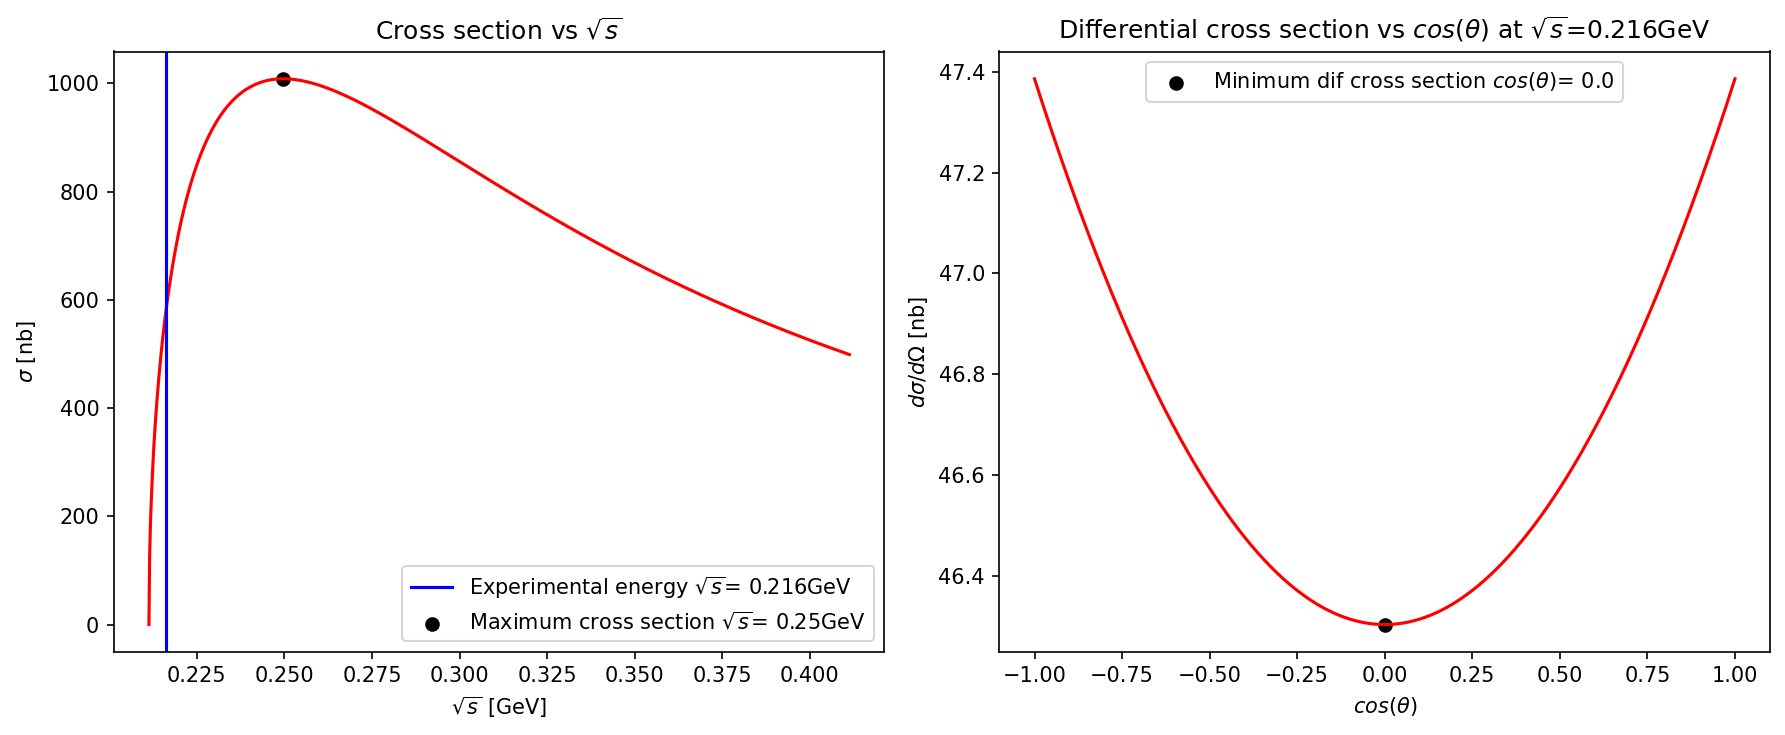

In [5]:
# getting some energy and theta values for plotting reasons
N_pts = 1000
E_values=np.linspace(2*mu_mass,2*mu_mass+0.2,N_pts)
theta_values=np.linspace(0,np.pi,N_pts)

# getting the coordinates for the max of the total cross section
idx = np.argmax(cross_section(s=E_values**2))
E_maxcs=E_values[idx]

# getting the coordinates for the min of the differential cross section
idx2=np.argmin(dif_cross_section(theta_values, s=E_sim**2))
theta_mincs=theta_values[idx2]

# plotting
fig, ax = plt.subplots(1,2, figsize=(12,5))
# pad 0
ax[0].plot(E_values,cross_section(E_values**2), c='r')
ax[0].axvline(E_sim, label=r'Experimental energy $\sqrt{s}$= '+ str(round(E_sim,3)) +"GeV", c='b')
ax[0].scatter(E_maxcs,cross_section(E_maxcs**2), label=r'Maximum cross section $\sqrt{s}$= '+ str(round(E_maxcs,3)) +"GeV", c='k')
ax[0].set_xlabel(r'$\sqrt{s}$ [GeV]')
ax[0].set_ylabel(r'$\sigma$ [nb]')
ax[0].set_title(r'Cross section vs $\sqrt{s}$')
ax[0].legend()
# pad 1
ax[1].plot(np.cos(theta_values),dif_cross_section(theta_values, s=E_sim**2), c='r')
ax[1].scatter(np.cos(theta_mincs),dif_cross_section(theta_mincs, s=E_sim**2), label=r'Minimum dif cross section $cos(\theta$)= '+ str(round(np.cos(theta_mincs),1)), c='k')
ax[1].set_xlabel(r'$cos(\theta)$')
ax[1].set_ylabel(r'$d\sigma/d\Omega$ [nb]')
ax[1].set_title(r'Differential cross section vs $cos(\theta)$ at $\sqrt{s}$='+ str(round(E_sim,3)) +"GeV")
ax[1].legend()
# showing
fig.tight_layout()

We have computed the total cross-section, which measures the probability that this process will take place. The cross-section is a function of the energy $\sqrt{s}$.

Let's analyze the first graph: for energies lower than $\sqrt{s} \sim 2m_{\mu}$, the process doesn't take place as the energy of the particles is not sufficient for the process to occur. Then, the total cross-section increases with energy until reaching a maximum at $\sqrt{s} = 0.25$ GeV, close to the low energy limit, where the process is more likely to take place. From higher energies, the cross-section slowly decreases, as particles with excessively more energy will collide less frequently, resulting in fewer processes taking place.


As for the second graph, we are going to study the differential cross-section, which is also a function of the scattering angle $\theta$, so are going to fix an experimental energy (also shown in graph 1) to study its dependence on $\cos{\theta}$. We can immediately observe a quadratic relation which is already reflected in the differential cross-section expression ($\frac{d\sigma}{d\Omega}\propto \cos{\theta}^{2}$). A minimum is found at $\cos{\theta} = 0$, corresponding to $\theta = 90^\degree$. This will be related to the angular distribution, which will be discussed in the next point.

### Point 2 
Compute and display the angle and momentum components distributions of the emerging muon pairs.

### Angle and momentum components distributions of the emerging muon pairs

The probability distribution function of the theta angle is given by ($ d\Omega=d\cos{\theta}d\phi)$:

$$
P(\theta) = \frac{d\sigma}{d\theta} = \int_{0}^{2\pi} d\phi \sin\theta \left(\frac{d\sigma}{d\Omega}\right) = 2\pi\sin\theta\left(\frac{d\sigma}{d\Omega}\right)
$$

We can also define a normalized (its integral in $\theta$ range, $[0,\pi]$, should be 1) function that goes by:

$$P(\theta)_{norm}=\frac{P(\theta)}{\sigma}$$

In [6]:
def pdf(theta, s=E_sim**2):
    return dif_cross_section(theta, s)*np.sin(theta)*2*np.pi

def pdf_norm(theta, s=E_sim**2):
    return pdf(theta, s)/cross_section(s)

#Normaization check
print('Value of the cross section: '+ str(round(cross_section(s=E_sim**2),3)))
print('Value integral pdf: '+  str(round(integrate.quad(lambda theta: pdf(theta, s=E_sim**2),0,np.pi)[0],3)))
print('Value integral pdf normalized: ', str(round(integrate.quad(lambda theta: pdf_norm(theta, s=E_sim**2),0,np.pi)[0],3)))

Value of the cross section: 586.403
Value integral pdf: 586.403
Value integral pdf normalized:  1.0


Now we can compute the angle distribution and see how it evolves when the energy is increased. For a better representation, we will use an animation:

In [7]:
# useful things
sqrt_s_plot = np.linspace(2*mu_mass+0.001, 0.6, 200)
s_tot = cross_section(sqrt_s_plot**2)
theta = np.linspace(0,180,180)
pdf_theta = pdf_norm(theta*np.pi/180, E_sim**2)

if (MODE==ps.kEDIT):
    # initialize the figure
    fig = plt.figure(figsize=(12,6))
    ax0 = plt.subplot2grid((1,2), loc=(0,0), rowspan=1, colspan=1, fig=fig)
    ax1 = plt.subplot2grid((1,2), loc=(0,1), rowspan=1, colspan=1, fig=fig)
    
    # setting stuff
    ax0.set_xlim(2*mu_mass, 0.6)
    ax1.set_xlim(0, 180)
    ax1.set_ylim(0, 0.009)
    ax0.set_xlabel(r'Center of mass energy $\sqrt{s} [GeV]$')
    ax0.set_ylabel(r'Total cross section $\sigma(\sqrt{s})$')
    ax0.set_title(r'Total cross section vs Center of mass energy')
    ax1.set_title(r'Production angle probability density function')
    ax1.set_xlabel(r'$\theta$ (degrees)')
    ax1.set_ylabel(r'Probability Density')
    fig.tight_layout()
    
    # line variables
    line_ax0, = ax0.plot(sqrt_s_plot, s_tot, lw = 3)
    linescat_ax0, = ax0.plot([], [], marker='o', color='red', markersize=10)
    vline_ax0, = ax0.plot([], [], color='red', lw=1.5, linestyle='dashed')
    line_ax1, = ax1.plot([], [], lw = 3)
    txt0 = ax0.text(0,0,0,c='red')
    
    # functions
    def init():
        linescat_ax0.set_data([], [])
        vline_ax0.set_data([], [])
        line_ax1.set_data([], [])
        return line_ax1
    
    def animate(i):
        # moving the point across the plot
        linescat_ax0.set_data(sqrt_s_plot[i], s_tot[i])
        # setting the vertical line
        vline_ax0.set_data([sqrt_s_plot[i],sqrt_s_plot[i]], [-1200,1200])
        # setting text
        if (sqrt_s_plot[i] < 0.4):    
            txt0.set_position((sqrt_s_plot[i]*1.02, s_tot[i]))
        else:
            txt0.set_position((sqrt_s_plot[i]*0.80, s_tot[i]*0.9))
        txt0.set_text(r'$\sqrt{s}='+str(round(sqrt_s_plot[i],2))+r'$ GeV')
        # calculating the pdf plot
        y_tmp = pdf_norm(theta*np.pi/180, sqrt_s_plot[i]**2)
        y = y_tmp/sum(y_tmp)
        line_ax1.set_data(theta, y)
         
        return line_ax1
        #return (linescat_ax0, line_ax1)
    
    anim = FuncAnimation(fig, animate, init_func = init, frames = 200, interval = 20, blit = False) 
    
    anim.save('CrossSec_ThetaPdf.mp4',  writer = 'ffmpeg', fps = 30)
    
    plt.close(fig)

/var/folders/nn/f6b1btbd1dgc4g_ddfnl2s3r0000gn/T/ipykernel_63709/3866265880.py:41: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  linescat_ax0.set_data(sqrt_s_plot[i], s_tot[i])


In [8]:
%%HTML
<div align="center">
    <video width="800" controls>
      <source src="CrossSec_ThetaPdf.mp4" type="video/mp4">
    </video>
</div>

From the animation, we can see how the angle distribution evolves, in the low energy region, when $\sqrt{s} \sim 2m_{\mu}$, we can see that we obtain a single maximum at $\theta = 90 \degree$. When the energy is increased the maximum starts to flatten and two maximums start to appear, now the angle distribution is more spread, with maximum probability in two angles.

This can be explained mathematicaly by observing $P(\theta)$ expression, which is proportional to $ \sin\theta\frac{d\sigma}{d\Omega}$. 

- Lower energies ( $\left(1-\frac{4m_{\mu}}{s}\right) \rightarrow 0$): the differential cross-section has a very low angular dependence, that is why the only angular dependence of the distribution is given by the sine:  $P(\theta) \propto \sin{\theta}$, which will give us the maximum probability at $\theta=90 \degree $.

- Higher energies ( $\frac{4m_{\mu}}{s}<<1$): we can approximate the differential cross section to $\left(\frac{d\sigma}{d\Omega}\right) \sim \frac{\alpha^2}{4s}\left(1+\cos^2\theta\right)$, consequently we will obtain an angular distribution of:$$P(\theta) \propto (1+\cos^2\theta)\sin{\theta}$$ $$\frac{dP(\theta)}{d\theta} \propto (1+\cos^2\theta)\cos\theta-2\cos\theta\sin^2\theta=0$$ Solving the equation we obtain three critical points: one minimum at $ 90 \degree$, and two maximums around the values $\sim 55 \degree$ and $\sim 125 \degree$, which are approximately the values that we can see in the distributions for high energies. 

### Point 3

### Lorentz Boosts
In the following calculations we use c=1. The four-momentum transforms as any four-vector under Lorenz transformation[7]. We can simply make a Lorentz boost:

\begin{align}
    E' &= \gamma(E - \beta p_z) \\
    p'_x &= p_x \\
    p'_y &= p_y \\
    p'_z &= \gamma(p_z - \beta E)
\end{align}

where $\beta = v_z$ and $\gamma = (1 - \beta^2)^{-1/2}$. 

#### CoM-to-Lab frame

We can now calculate the velocity of the incoming positron:

\begin{equation*}
    \beta_{\text{CoM}} = v_z=\frac{p'_z}{E'_1+m_2} =\frac {\sqrt{E_1^2 - m_e^2}}{E'_1+m_e}=\sqrt{\frac{E_1^2-m_e^2}{(E_1+m_e)^2}}\approx\sqrt{1 - \frac{m_e^2}{E^2}}=\sqrt{1- \frac{4m_e^2}{s}}
\end{equation*}

In [60]:
momentum = np.sqrt((E_sim / 2) ** 2 - (e_mass**2)) #positron momentum using the relativistic formula
gamma = E_sim / (2 * e_mass) # Lorentz gamma factor
print(gamma)

# Computes Lorentz-transformed variables
def lorentz_boost(E, px, py, pz, gamma):

    v = -np.sqrt(1 - 1 / gamma ** 2 ) # Calculate velocity
    pz_t = gamma * (pz - E * v) #Transformed momentum along z-axis
    E_t = gamma * (E - pz * v) #Transformed energy
     
    return E_t, px, py, pz_t, v

v=lorentz_boost(E_sim/2, 0,0, momentum, gamma) #Compute the velocity using Lorentz transformation

#In the Lorentz transformation, only the momentum component along the z-axis (pz) is altered,
#while the components along the x-axis (px) and y-axis (py) remain unchanged.
print("Velocity (v):", v[4])
print("Lorentz gamma factor:", gamma)
print("Energy:", v[0])

211.66066065199658
Velocity (v): -0.9999888392820437
Lorentz gamma factor: 211.66066065199658
Energy: 45.78523501464573


### Point 4
### Monte Carlo simulations

In [41]:
import psutil
import os
import time
from scipy.stats import uniform
from scipy.optimize import brentq
from scipy.stats import chisquare
process = psutil.Process(os.getpid())

def pdf_norm_wrap(angle,s=E_sim**2):
    return pdf_norm(angle*np.pi/180, s=s)*np.pi/180

iterations=10**5

#### Hit or Miss Monte Carlo Method

The Hit or Miss Monte Carlo method[1] is a technique used for estimating the integral of a function, or more generally, the area under a curve. This method is particularly useful when dealing with complex integrals that are difficult to solve analytically. It relies on stochastic sampling to approximate the value of the integral.

Consider a function $f(x)$ defined over an interval $[a, b]$. The objective is to construct a sample distribution that fills the area beneath the function.

The method involves the following steps:

1. **Enclose the function within a rectangle**: The rectangle has width $(b-a)$ and height $h$, where $h$ is chosen such that it is greater than or equal to the maximum value of $f(x)$ in the interval $[a, b]$.

2. **Randomly sample points within the rectangle**: Generate $N$ random points $(x_i, y_i)$, where $x_i$ is uniformly distributed over $[a, b]$ and $y_i$ is uniformly distributed over $[0, h]$.

3. **Determine hits and misses**: A point $(x_i, y_i)$ is considered a "hit" if $y_i \leq f(x_i)$. Otherwise, it is a "miss".

4. **Assemble the dataset of "hit" points**: Store each "hit" point in an array accessible via a variable, prepared for plotting.

In [42]:
def hit_or_miss(distribution, num_samples, x_range, y_range):
    x_samples = np.random.uniform(*x_range, num_samples)
    y_samples = np.random.uniform(*y_range, num_samples)
    hits = y_samples <= distribution(x_samples)
    return x_samples[hits]

angles=np.arange(0,180,1)
angle_range = (np.min(angles), np.max(angles))
pdf_range = (np.min(pdf_norm_wrap(angles)), np.max(pdf_norm_wrap(angles)))

mem_before_hm = process.memory_info().rss / 1024 / 1024
start_time_hm = time.time()
theta_samples_hm = hit_or_miss(pdf_norm_wrap, iterations, angle_range, pdf_range)
end_time_hm = time.time()
mem_after_hm = process.memory_info().rss / 1024 / 1024
    
time_hm = round((end_time_hm - start_time_hm),3)
mem_usage_hm = round((mem_after_hm - mem_before_hm),3)
accepted_hm = round((len(theta_samples_hm)/iterations),3)

print(f"Execution time: {time_hm} seconds")
print(f"Memory usage: {mem_usage_hm} MB")
print(f"Accepted rate: {accepted_hm}")

Execution time: 0.01 seconds
Memory usage: 4.062 MB
Accepted rate: 0.647


#### Importance Sampling Method

Importance Sampling[2] is a variance reduction technique utilized in Monte Carlo simulations for estimating the expected value of a function. This method proves particularly beneficial for functions exhibiting regions of significant variability by aiming to decrease the estimate's variance through more frequent sampling from these critical areas of the function.

The essence of Importance Sampling lies in converting the original expectation problem into a form that exhibits lower variance, thereby enhancing the efficiency of the estimation. Consider a function $f(x)$ defined across a domain $D$. Let $p(x)$ represent a probability density function (PDF) over $D$, from which sampling is feasible. The expected value of $f(x)$ is expressed as:

$$E[f(x)] = \int_D f(x)p(x)dx$$

In instances where direct sampling from $p(x)$ proves inefficient due to the variability of $f(x)$, an alternative PDF, $q(x)$, is employed for sampling. This alternative requires $q(x) > 0$ wherever the product $f(x)p(x) \neq 0$. Consequently, the expected value of $f(x)$ can be reformulated as:

$$E[f(x)] = \int_D \frac{f(x)p(x)}{q(x)}q(x)dx$$

In this equation, $\frac{f(x)p(x)}{q(x)}$ denotes the weighted function, with $q(x)$ serving as the importance sampling distribution.

The methodology encompasses the following steps:

1. **Choose an appropriate importance sampling distribution**: Select a $q(x)$ that mirrors the form of $f(x)p(x)$, yet facilitates easier sampling. The selection of $q(x)$ aims to reduce the variance associated with the weighted function.

2. **Sample points**: Draw samples ${x_i}$ from the distribution $q(x)$.

3. **Compute the weights**: Assign weights to each sampled point according to $w(x_i) = \frac{p(x_i)}{q(x_i)}$. These weights are normalized to ensure they sum to 1, enhancing the representativeness of the sample.

4. **Generate the weighted sample set**: Utilizing the weights computed in step 3, a weighted sample set is constructed by selecting points from the initially sampled distribution. This selection is performed with probability proportional to the computed weights, thereby assembling a dataset reflective of the target distribution's characteristics.

In [43]:
theta_range=(0, 180)

def importance_sampling(iterations, pdf_target_norm, proposal_pdf=None):
    theta_samples_prop = np.random.uniform(theta_range[0], theta_range[1], iterations)
    
    if proposal_pdf is None:
        proposal_pdf_values = uniform.pdf(theta_samples_prop, theta_range[0], theta_range[1] - theta_range[0])
    else:
        proposal_pdf_values = proposal_pdf(theta_samples_prop, s=E_sim**2)
    
    weights = np.maximum(pdf_target_norm(theta_samples_prop, s=E_sim**2) / proposal_pdf_values, 0)
    weights /= np.sum(weights)
    
    theta_samples_imp = np.random.choice(theta_samples_prop, size=iterations, p=weights)
    
    return theta_samples_imp

mem_before_imp = process.memory_info().rss / 1024 / 1024
start_time_imp = time.time()
theta_samples_imp = importance_sampling(iterations, pdf_norm_wrap)
end_time_imp = time.time()
mem_after_imp = process.memory_info().rss / 1024 / 1024

time_imp = round((end_time_imp - start_time_imp),3)
mem_usage_imp = round((mem_after_imp - mem_before_imp),3)
accepted_imp = round((len(theta_samples_imp)/iterations),3)

print(f"Execution time: {time_imp} seconds")
print(f"Memory usage: {mem_usage_imp} MB")
print(f"Accepted rate: {accepted_imp}")

Execution time: 0.038 seconds
Memory usage: 4.406 MB
Accepted rate: 1.0


#### Metropolis-Hastings Algorithm

The Metropolis-Hastings algorithm[3] is a branch of the Markov Chain Monte Carlo (MCMC) methods, designed to generate a sequence of samples from a probability distribution for which direct sampling poses significant challenges. 
By generating a sequence of samples, the Metropolis-Hastings algorithm ensures that, over a large number of samples, the distribution of these samples converges to the target distribution.

The methodology encompasses the following steps:

1. **Initialization**: Start with an initial sample $x_0$, serving as the beginning point of the Markov chain. This sample can be an arbitrary value that falls within the domain of the probability distribution of interest.

2. **Iteration Process**: Each iteration $i$ of the algorithm involves the following steps:
   - A new candidate sample $x'$ is proposed, generated from a normal distribution centered around the current sample with a standard deviation defined by the parameter `passes`. This normal distribution serves as the proposal distribution $q(x'|x_i)$.
   - The acceptance probability $A(x', x_i) = \min\left(1, \frac{p(x')q(x_i|x')}{p(x_i)q(x'|x_i)}\right)$ is calculated, where $p(x)$ represents the value of the target distribution at $x$, and $s$ is a predefined parameter influencing the acceptance ratio. This correctly includes $q(x_i|x')$ and $q(x'|x_i)$ to reflect the proposal distribution's role in the acceptance probability.
   - The candidate $x'$ is accepted with probability $A(x', x_i)$. Upon acceptance, $x_{i+1} = x'$; otherwise, $x_{i+1} = x_i$.
3. **Convergence Criterion**: The iteration continues until the samples adequately represent the target distribution, which may be judged by the total number of iterations or an assessment of the sample distribution's stability over iterations.

In [44]:
def metropolis_hastings(distribution, initial_sample, interations, passes, s=E_sim**2):
    current_sample = initial_sample
    samples = [current_sample]
    accepted = 0
    
    for i in range(iterations):
        new_sample = np.random.normal(current_sample, passes) #proposal distribution
        acceptance_ratio = distribution(new_sample, s) / distribution(current_sample, s)
        
        if (np.random.uniform(0,1,1) <= acceptance_ratio):
            current_sample = new_sample
            accepted += 1
        samples.append(current_sample)
        
    return np.asarray(samples),accepted

initial_sample = 90
passes = 7.5

mem_before_mh = process.memory_info().rss / 1024 / 1024
start_time_mh = time.time()
theta_samples_mh, accepted = metropolis_hastings(pdf_norm_wrap, initial_sample, iterations, passes)
end_time_mh = time.time()
mem_after_mh = process.memory_info().rss / 1024 / 1024

time_mh = round((end_time_mh - start_time_mh),3)
mem_usage_mh = round(mem_after_mh - mem_before_mh,3)
accepted_mh = round((len(theta_samples_mh)/iterations),3)

print(f"Execution time: {time_mh} seconds")
print(f"Memory usage: {mem_usage_mh} MB")
print(f"Accepted rate: {accepted_mh}")

Execution time: 0.962 seconds
Memory usage: 1.578 MB
Accepted rate: 1.0


#### Inverse Sampling Method

The Inverse Sampling method[4] is utilized for generating random samples from a distribution when direct sampling is complex or infeasible. This method is particularly effective for distributions that are not standard or easily accessible through conventional random number generators.

Inverse Sampling transforms uniformly distributed random numbers into samples from a target distribution by utilizing the inverse of the Cumulative Distribution Function (CDF) of the target distribution. This transformation hinges on the principle that if a random variable $Y$ is uniformly distributed, then the variable $X = F^{-1}(Y)$ follows the distribution $F$, where $F$ is the CDF of the target distribution.

The provided `inverse_sampling` function demonstrates this method through several steps:

1. **Define the Target PDF**: A probability density function (PDF) for $\cos(\theta)$, relevant to particle physics distributions, is defined. This function, `pdf_cos`, calculates the density based on parameters such as the angle $\theta$, the fine structure constant, the muon mass, and a normalization factor to ensure the PDF integrates to 1 over its domain.

2. **Normalize the PDF**: The PDF is normalized over its domain to ensure that its total integral equals 1, creating a valid probability density function, `pdf_cos_norm`.

3. **Compute the Inverse of the CDF**: Instead of directly computing the CDF and then its inverse, the `inverse_sampling` function employs the `brentq` method to find zeros of the function `cdf_zeros`—effectively solving for $x$ in the equation $F(x) = y$ where $y$ is a uniformly distributed random number. This approach utilize the CDF's properties indirectly to generate samples corresponding to the target distribution.

4. **Generate Uniform Samples and Transform**: Uniform random samples are generated, representing $y$ values. Each uniform sample is transformed into a sample from the target distribution by finding the corresponding $\theta$ value that satisfies the inverse CDF equation through the `cdf_zeros` function.

In [45]:
def inverse_sampling(iterations):
    def pdf_cos(z, s=E_sim**2):
        return (((fsc**2) * np.pi * 2 / (4 * s)) * np.sqrt(1 - (4 * mu_mass**2 / s)) *
                ((1 + (4 * mu_mass**2 / s)) + (1 - (4 * mu_mass**2 / s)) * z**2)) * 0.389379e6

    cost_norm_cos = integrate.quad(lambda z: pdf_cos(z), -1, 1)[0]

    def pdf_cos_norm(z, s=E_sim**2):
        return pdf_cos(z, s) / cost_norm_cos

    def cdf_zeros(y, x, s=E_sim**2):
        cost = ((fsc**2) * np.pi * 2 / (4 * s)) * np.sqrt(1 - (4 * mu_mass**2 / s)) * conv
        norm_cost = cross_section(s)
        return (-cost / norm_cost) * (1/3 * (1 - (4 * mu_mass**2 / s)) *
                                      y**3 + (1 + (4 * mu_mass**2 / s)) * y - 4/3 * (1 + 2 * mu_mass**2 / s)) - x

    r_samples = np.random.uniform(0, 1, iterations)
    theta_samples_is = [brentq(cdf_zeros, -1, 1, args=(r,)) for r in r_samples]

    return theta_samples_is

mem_before_is = process.memory_info().rss / 1024 / 1024
start_time_is = time.time()
theta_samples_is = inverse_sampling(iterations)
end_time_is = time.time()
mem_after_is = process.memory_info().rss / 1024 / 1024

time_is = round((end_time_is - start_time_is),3)
mem_usage_is = round((mem_after_is - mem_before_is),3)
accepted_is = round((len(theta_samples_is)/iterations),3)
theta_samples_isc = 180*np.arccos(theta_samples_is)/np.pi

print(f"Execution time: {time_is} seconds")
print(f"Memory usage: {mem_usage_is} MB")
print(f"Accepted rate: {accepted_is}")

Execution time: 1.392 seconds
Memory usage: 0.625 MB
Accepted rate: 1.0


#### Sequential Monte Carlo Method

The Sequential Monte Carlo (SMC) method[5], also known as particle filtering, is used for approximating posterior distributions. This method is especially useful in situations where the target distribution evolves over time or is otherwise difficult to sample from directly due to its complexity.

SMC works by maintaining a set of samples, often referred to as "particles," which represent the posterior distribution of interest. These particles are propagated through time (or iterations) using two main steps: resampling based on weights derived from the target distribution, and moving the particles via a proposal distribution. This process adjusts the density of particles to more closely resemble the target distribution over iterations.

The `sequential_monte_carlo` function illustrates a basic SMC algorithm through several steps:

1. **Initial Sampling**: Initially, particles (samples) $\theta$ are drawn uniformly from the proposal range.

2. **Iteration and Weighting**: For a given number of steps, the particles are weighted according to their likelihood under the target distribution `pdf_target_norm`. These weights represent the relevance of each particle in approximating the target distribution.

3. **Normalization of Weights**: The weights are normalized to ensure they sum to 1, allowing them to be used for the next step.

4. **Resampling**: Based on the calculated weights, a resampling step is performed where particles are probabilistically selected to form the next generation of samples. This selection process favors particles with higher weights, thus steering the ensemble towards regions of higher probability under the target distribution.

In [46]:
def sequential_monte_carlo(iterations, pdf_target_norm, steps=1):
    theta_samples_se = np.random.uniform(theta_range[0], theta_range[1], iterations)
    
    for step in range(steps):
        weights = pdf_target_norm(theta_samples_se, s=E_sim**2)
        weights /= np.sum(weights)
        theta_samples_se = np.random.choice(theta_samples_se, size=iterations, p=weights)
    
    return theta_samples_se

mem_before_se = process.memory_info().rss / 1024 / 1024
start_time_se = time.time()
theta_samples_se = sequential_monte_carlo(iterations, pdf_norm_wrap, steps=1)
end_time_se = time.time()
mem_after_se = process.memory_info().rss / 1024 / 1024

time_se = round((end_time_se - start_time_se),3)
mem_usage_se = round((mem_after_se - mem_before_se),3)
accepted_se = round((len(theta_samples_se)/iterations),3)

print(f"Execution time: {time_se} seconds")
print(f"Memory usage: {mem_usage_se} MB")
print(f"Accepted rate: {accepted_se}")

Execution time: 0.02 seconds
Memory usage: 3.453 MB
Accepted rate: 1.0


#### Stratified Sampling Method

Stratified Sampling[6] is a method used in Monte Carlo simulations to improve the accuracy and efficiency of estimations by dividing the population into distinct subgroups, or strata, and sampling from each stratum separately.

The `stratified_sampling` function implements stratified sampling with the following steps:

1. **Domain Partitioning**: The domain, described by a range, is divided into `strata` number of equal intervals. Each interval represents a stratum from which samples are drawn.

2. **Stratum-Specific Sampling**:
    - For each stratum, the integral of the target probability density function (PDF), `pdf_target_norm`, over the stratum's range is computed. This integral represents the stratum's contribution to the total integral over the entire domain.
    - Based on this contribution, a proportionate number of samples, `stratum_samples_count`, is determined for each stratum. This ensures that strata with higher values contribute more samples, aligning the sampling process with the distribution's density.

3. **Sample Generation**: Within each stratum, `stratum_samples_count` samples are generated uniformly. These samples are then aggregated to form the final set of samples, `theta_samples_st`.

4. **Normalization and Aggregation**: The samples from all strata are combined to create a comprehensive sample set that reflects the overall distribution's characteristics more accurately than simple random sampling.

In [47]:
def stratified_sampling(iterations, pdf_target_norm, strata=10):
    
    theta_samples_st = np.array([])
    total_integral = integrate.quad(pdf_target_norm, theta_range[0], theta_range[1])[0]

    for stratum in range(strata):
        stratum_start = theta_range[0] + (theta_range[1] - theta_range[0]) * (stratum / strata)
        stratum_end = theta_range[0] + (theta_range[1] - theta_range[0]) * ((stratum + 1) / strata)
        
        stratum_integral = integrate.quad(pdf_target_norm, stratum_start, stratum_end)[0]
        
        stratum_samples_count = int((stratum_integral / total_integral) * iterations)
        
        if stratum_samples_count > 0:
            stratum_samples = np.random.uniform(stratum_start, stratum_end, stratum_samples_count)
            theta_samples_st = np.concatenate((theta_samples_st, stratum_samples))

    return theta_samples_st
    
strata = 100

mem_before_st = process.memory_info().rss / 1024 / 1024
start_time_st = time.time()
theta_samples_st = stratified_sampling(iterations, pdf_norm_wrap, strata=strata)
end_time_st = time.time()
mem_after_st = process.memory_info().rss / 1024 / 1024

time_st = round((end_time_st - start_time_st),3)
mem_usage_st = round((mem_after_st - mem_before_st),3)
accepted_st = round((len(theta_samples_st)/iterations),3)

print(f"Execution time: {time_st} seconds")
print(f"Memory usage: {mem_usage_st} MB")
print(f"Accepted rate: {accepted_st}")

Execution time: 0.02 seconds
Memory usage: 3.672 MB
Accepted rate: 0.999


#### Plotting

In the upcoming plot, we will present histograms of the angle $\theta$ generated by each Monte Carlo method. Each histogram will illustrate the frequency distribution of the sampled angles, providing an empirical representation of the underlying probability density function (PDF). To enhance the clarity and interpretability of these histograms, we will overlay the theoretical PDF of $\theta$ as a reference, enabling a direct visual comparison between the empirical and theoretical distributions.
Error bars will be included to represent the statistical uncertainty of the histogram bins. These error bars are calculated as the square root of the observed counts in each bin, normalized by the total number of samples and the bin width. This will help in understanding the variability and reliability of the sampled data.

To provide a comprehensive assessment of each method, we will annotate each subplot with critical performance metrics:

- Execution Time: The total time taken to generate the samples for each method.
- Memory Usage: The memory consumption during the sampling process.
- Acceptance Rate: The proportion of proposed samples accepted by each method, indicating its efficiency.
- Chi-Squared Statistic: A measure of goodness-of-fit between the observed sample distribution and the expected theoretical distribution. Lower chi-squared values suggest a closer fit to the theoretical PDF.

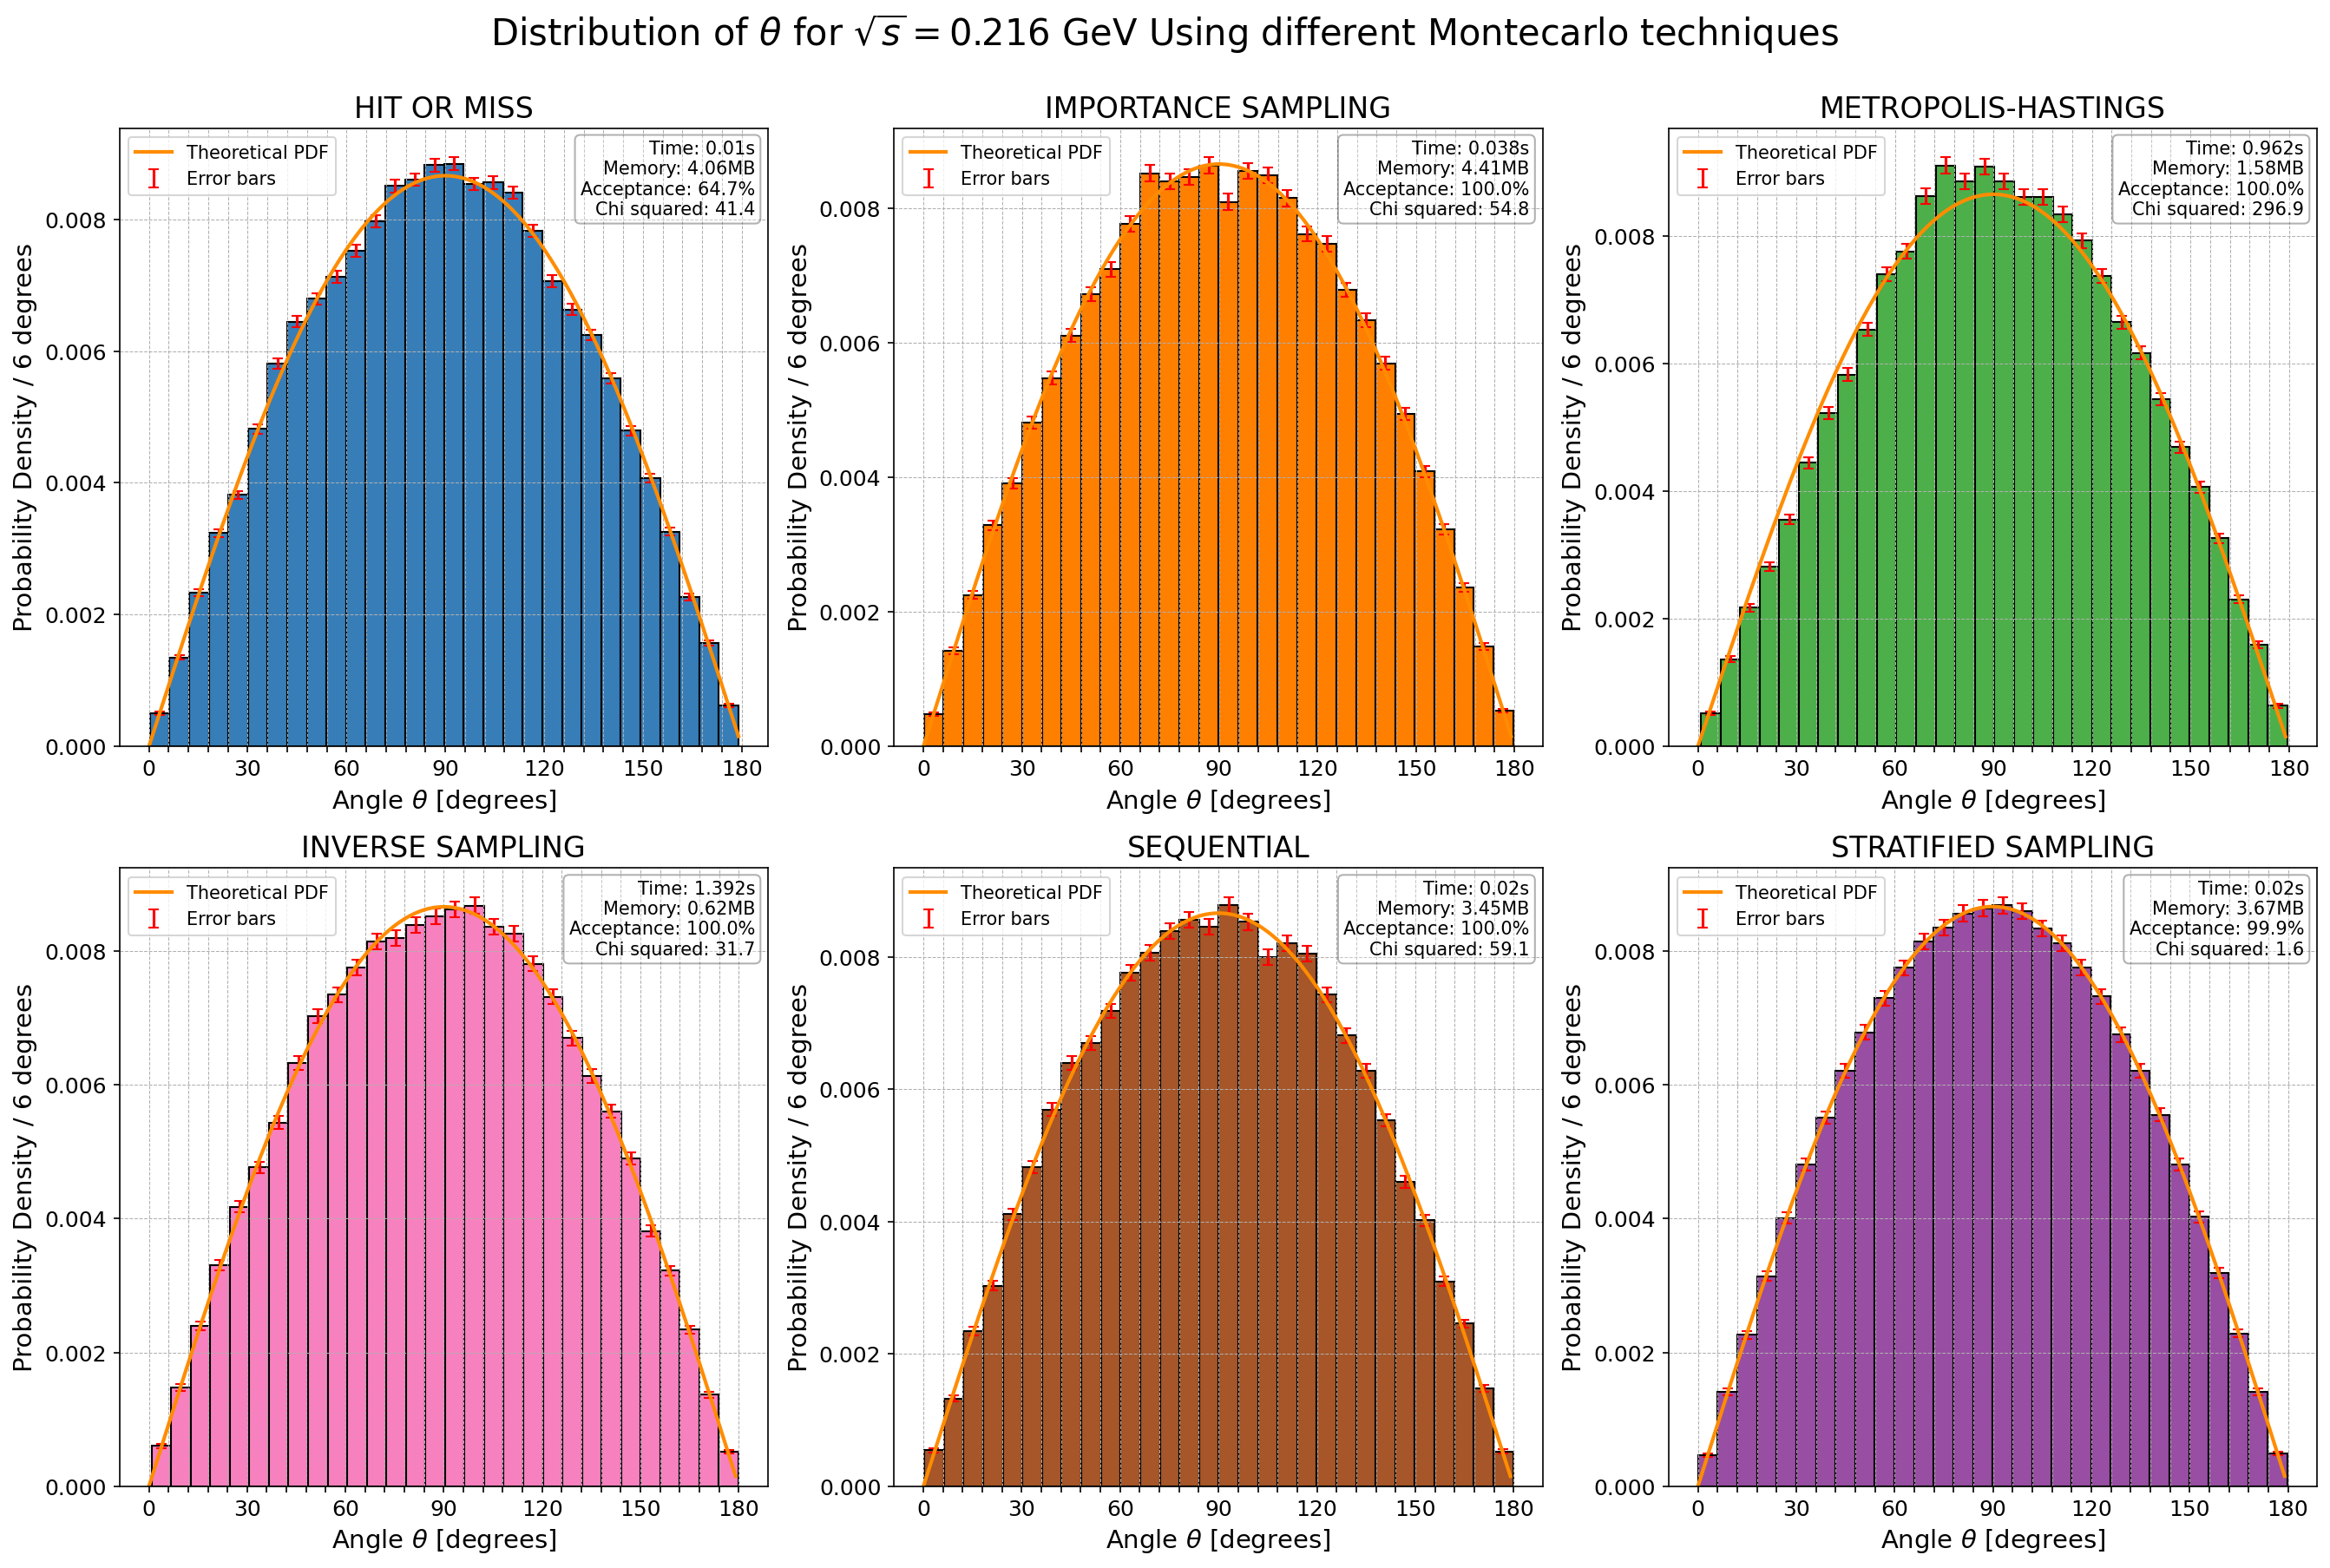

             Method Time (s) Memory (MB) Acceptance (%) Chi Squared
        HIT OR MISS     0.01        4.06          64.70       41.44
IMPORTANCE SAMPLING     0.04        4.41         100.00       54.83
METROPOLIS-HASTINGS     0.96        1.58         100.00      296.90
   INVERSE SAMPLING     1.39        0.62         100.00       31.73
         SEQUENTIAL     0.02        3.45         100.00       59.05
STRATIFIED SAMPLING     0.02        3.67          99.90        1.61


In [48]:
names = ["HIT OR MISS","IMPORTANCE SAMPLING","METROPOLIS-HASTINGS","INVERSE SAMPLING","SEQUENTIAL","STRATIFIED SAMPLING"]
methods = ["hm","imp","mh","isc","se","st"]
colors = ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3"]
times = [time_hm, time_imp, time_mh, time_is, time_se, time_st]
mem_usages = [mem_usage_hm, mem_usage_imp, mem_usage_mh, mem_usage_is, mem_usage_se, mem_usage_st]
acceptances = [accepted_hm, accepted_imp, accepted_mh, accepted_is, accepted_se, accepted_st]
chis_t = []


for method in methods:
    dataset = globals()[f"theta_samples_{method}"]
    observed_counts, bins = np.histogram(dataset, bins=30, density=False)
    bin_widths = np.diff(bins)
    expected_probs = np.array([quad(pdf_norm_wrap, bins[i], bins[i+1])[0] for i in range(len(bins)-1)])
    expected_counts = expected_probs / sum(expected_probs) * sum(observed_counts)
    chi_squared_stat_t = chisquare(f_obs=observed_counts, f_exp=expected_counts)
    chis_t.append(chi_squared_stat_t.statistic)

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
total_samples = len(dataset)

for i, (method, time, mem_usage, acceptance, chi) in enumerate(zip(methods, times, mem_usages, acceptances, chis_t)):
    dataset = globals()[f"theta_samples_{method}"]

    counts, bins = np.histogram(dataset, bins=30)
    bin_width = np.diff(bins)
    errors = np.sqrt(counts) / (total_samples * bin_width)
    
    counts, bins, patches = axs[i].hist(dataset, bins=30, density=True, color=colors[i], edgecolor="black")
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width = np.diff(bins)
    
    axs[i].errorbar(bin_centers, counts, yerr=errors, fmt="none", ecolor="r", capsize=3, label="Error bars")
    axs[i].plot(angles, pdf_norm_wrap(angles), color="darkorange", linewidth=2, label="Theoretical PDF")
    axs[i].set_title(names[i], fontsize=16)
    axs[i].set_xlabel(r"Angle $\theta$ [degrees]", fontsize=14)
    axs[i].set_ylabel("Probability Density / 6 degrees", fontsize=14)
    axs[i].legend(loc="upper left", fontsize=10)
    axs[i].grid(True, which="both", linestyle="--", linewidth=0.5)
    axs[i].set_xticks(np.arange(0, 181, 6))
    axs[i].set_xticklabels([str(degree) if degree % 30 == 0 else '' for degree in np.arange(0, 181, 6)])
    axs[i].tick_params(axis="both", which="major", labelsize=12)
    info_text = f"Time: {time}s\nMemory: {mem_usage:.2f}MB\nAcceptance: {acceptance*100:.1f}%\nChi squared: {chi:.1f}"
    axs[i].text(0.98, 0.98, info_text, transform=axs[i].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.3, boxstyle="round,pad=0.3"))

fig.suptitle(r"Distribution of $\theta$ for $\sqrt{s}=$" + str(round(E_sim, 3)) + " GeV Using different Montecarlo techniques",
             fontsize=20, y=1.0)

plt.tight_layout()
plt.show()

column_labels = ["Method", "Time (s)", "Memory (MB)", "Acceptance (%)", "Chi Squared"]
table_data = [
    [names[i], f"{times[i]:.2f}", f"{mem_usages[i]:.2f}", f"{acceptances[i] * 100:.2f}", f"{chis_t[i]:.2f}"]
    for i in range(len(names))
]

df = pd.DataFrame(table_data, columns=column_labels)
print(df.to_string(index=False))

#### Babayaga Comparison

For this comparison the goal is to analyze each distribution with the Babayaga algorithm.
BabaYaga is a Monte Carlo event generator designed for $e^+e^-$ collisions into $e^+e^-$, $\mu^+\mu^-$, $\gamma\gamma$, and $\pi^+\pi^-$ at energies below 10-12 GeV, developed by C.M. Carloni Calame, G. Montagna, O. Nicrosini, and F. Piccinini at INFN Pavia. More information can be found on its [official webpage](https://www2.pv.infn.it/~hepcomplex/babayaga.html).

The theoretical prediction for the $\theta$ distribution, as provided by the BabaYaga event generator, will be superimposed on each histogram for comparison. This will enable us to evaluate how closely the empirical distributions generated by the Monte Carlo methods match the BabaYaga prediction.

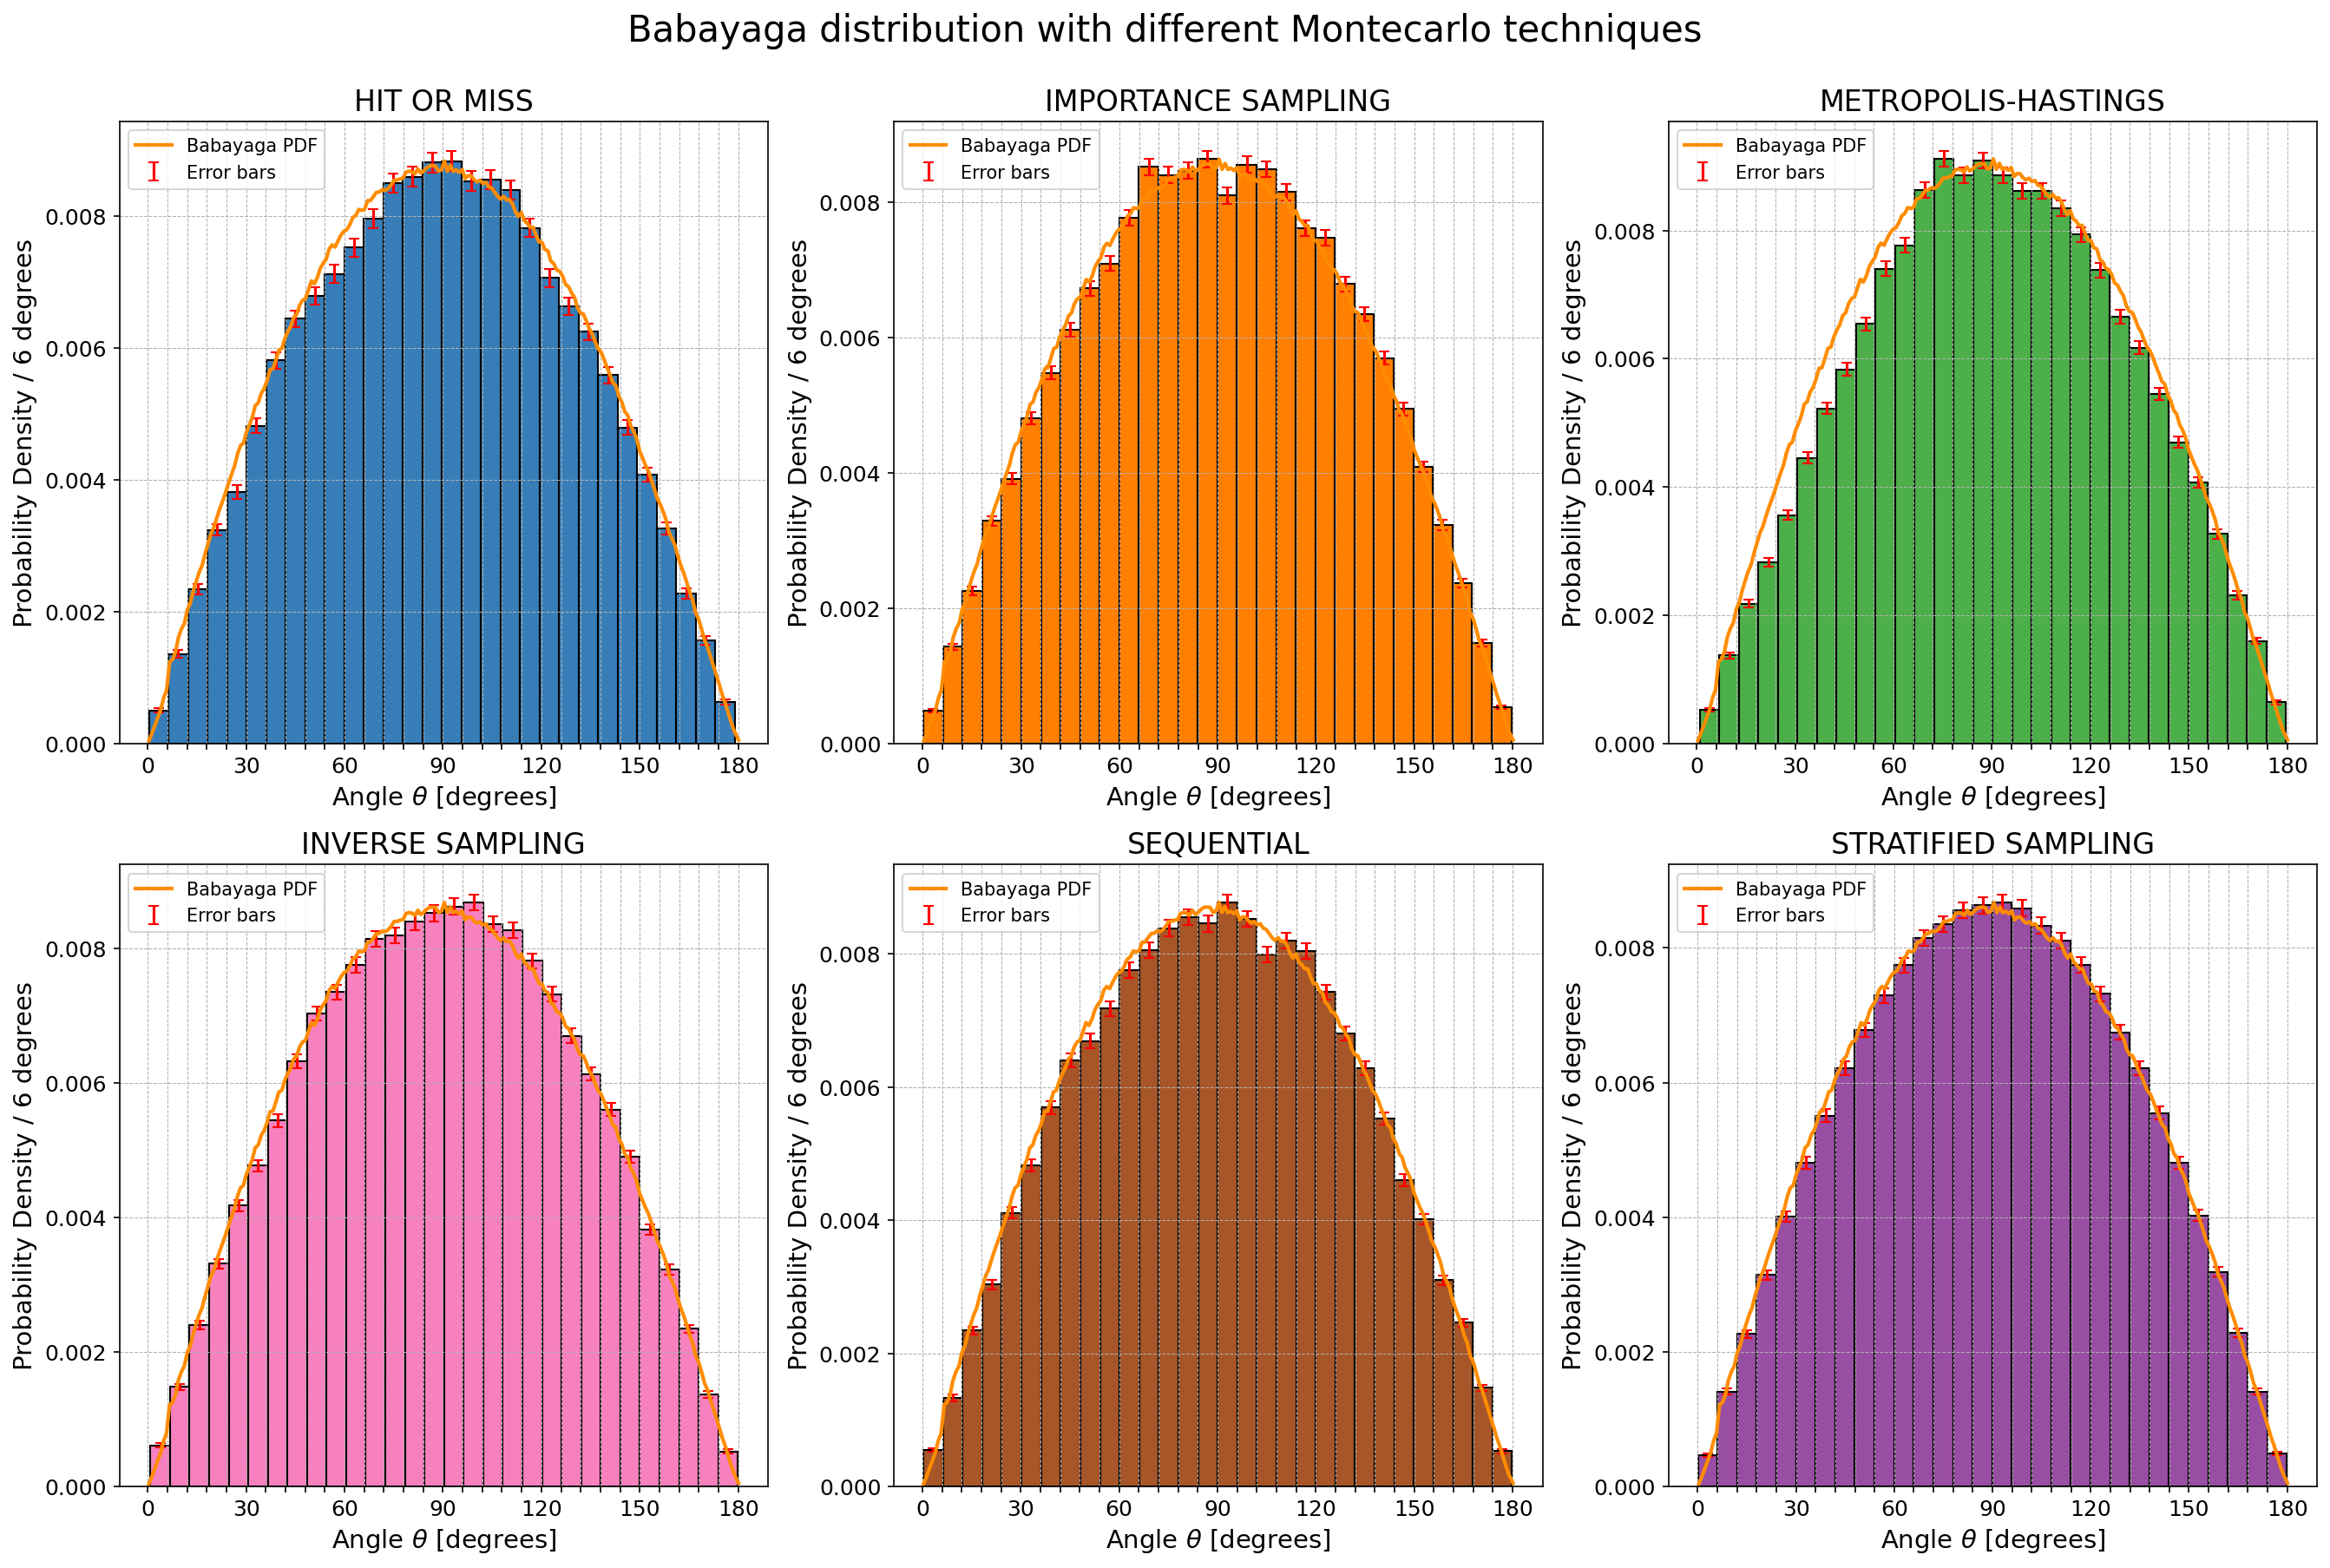

             Method Time (s) Memory (MB) Acceptance (%) Reduced Chi Squared (Babayaga)
        HIT OR MISS     0.01        4.06          64.70                          15.62
IMPORTANCE SAMPLING     0.04        4.41         100.00                          28.92
METROPOLIS-HASTINGS     0.96        1.58         100.00                          38.28
   INVERSE SAMPLING     1.39        0.62         100.00                          25.96
         SEQUENTIAL     0.02        3.45         100.00                          23.92
STRATIFIED SAMPLING     0.02        3.67          99.90                          21.87


In [49]:
Babayaga = np.loadtxt("matched_el_th_exp_200.txt").T

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
chis_b = []

fitted_parameters = 0

for i, method in enumerate(methods):
    dataset = globals()[f"theta_samples_{method}"]
    
    counts, bins, patches = axs[i].hist(dataset, bins=30, density=True, color=colors[i], edgecolor="black")

    k = np.max(Babayaga[1]) / np.max(counts)
    baba_plotted = Babayaga[1] / k
    centers = [Babayaga[0][j] + (Babayaga[0][j+1] - Babayaga[0][j]) / 2 for j in np.arange(len(Babayaga[0]) - 1)]
    centers.append(Babayaga[0][-1] + (Babayaga[0][-1] - Babayaga[0][-2]))
    
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width = np.diff(bins)
    total_samples = len(dataset)
    errors = np.sqrt(counts / (total_samples * bin_width))
    axs[i].errorbar(bin_centers, counts, yerr=errors, fmt="none", ecolor="r", capsize=3, label="Error bars")
    
    axs[i].plot(centers, baba_plotted, color="darkorange", linewidth=2, label="Babayaga PDF")
    axs[i].set_title(names[i], fontsize=16)
    axs[i].set_xlabel(r"Angle $\theta$ [degrees]", fontsize=14)
    axs[i].set_ylabel("Probability Density / 6 degrees", fontsize=14)
    axs[i].legend(loc="upper left", fontsize=10)
    axs[i].grid(True, which="both", linestyle="--", linewidth=0.5)
    axs[i].set_xticks(np.arange(0, 181, 6))
    axs[i].set_xticklabels([str(degree) if degree % 30 == 0 else '' for degree in np.arange(0, 181, 6)])
    axs[i].tick_params(axis="both", which="major", labelsize=12)

    observed_counts, _ = np.histogram(dataset, bins=bins, density=False)
    expected_counts, _ = np.histogram(Babayaga[0], bins=bins, weights=Babayaga[1], density=False)
    scaling_factor = observed_counts.sum() / expected_counts.sum()
    expected_counts *= scaling_factor
    
    chi_squared_stat_b = chisquare(f_obs=observed_counts, f_exp=expected_counts)
    
    degrees_of_freedom = len(bins) - 1 - fitted_parameters
    
    reduced_chi_squared_b = chi_squared_stat_b.statistic / degrees_of_freedom
    chis_b.append(reduced_chi_squared_b)

fig.suptitle(r"Babayaga distribution with different Montecarlo techniques", fontsize=20, y=1.0)
plt.tight_layout()
plt.show()

column_labels = ["Method", "Time (s)", "Memory (MB)", "Acceptance (%)", "Reduced Chi Squared (Babayaga)"]
table_data = [
    [names[i], f"{times[i]:.2f}", f"{mem_usages[i]:.2f}", f"{acceptances[i] * 100:.2f}", f"{chis_b[i]:.2f}"]
    for i in range(len(names))
]

df = pd.DataFrame(table_data, columns=column_labels)
print(df.to_string(index=False))

In this plot, we delve deeper into the Stratified Sampling Monte Carlo method, which has shown better performance metrics. The comparison between the generated sampling, the theoretical pdf and the Babayaga pdf is visually represented below.

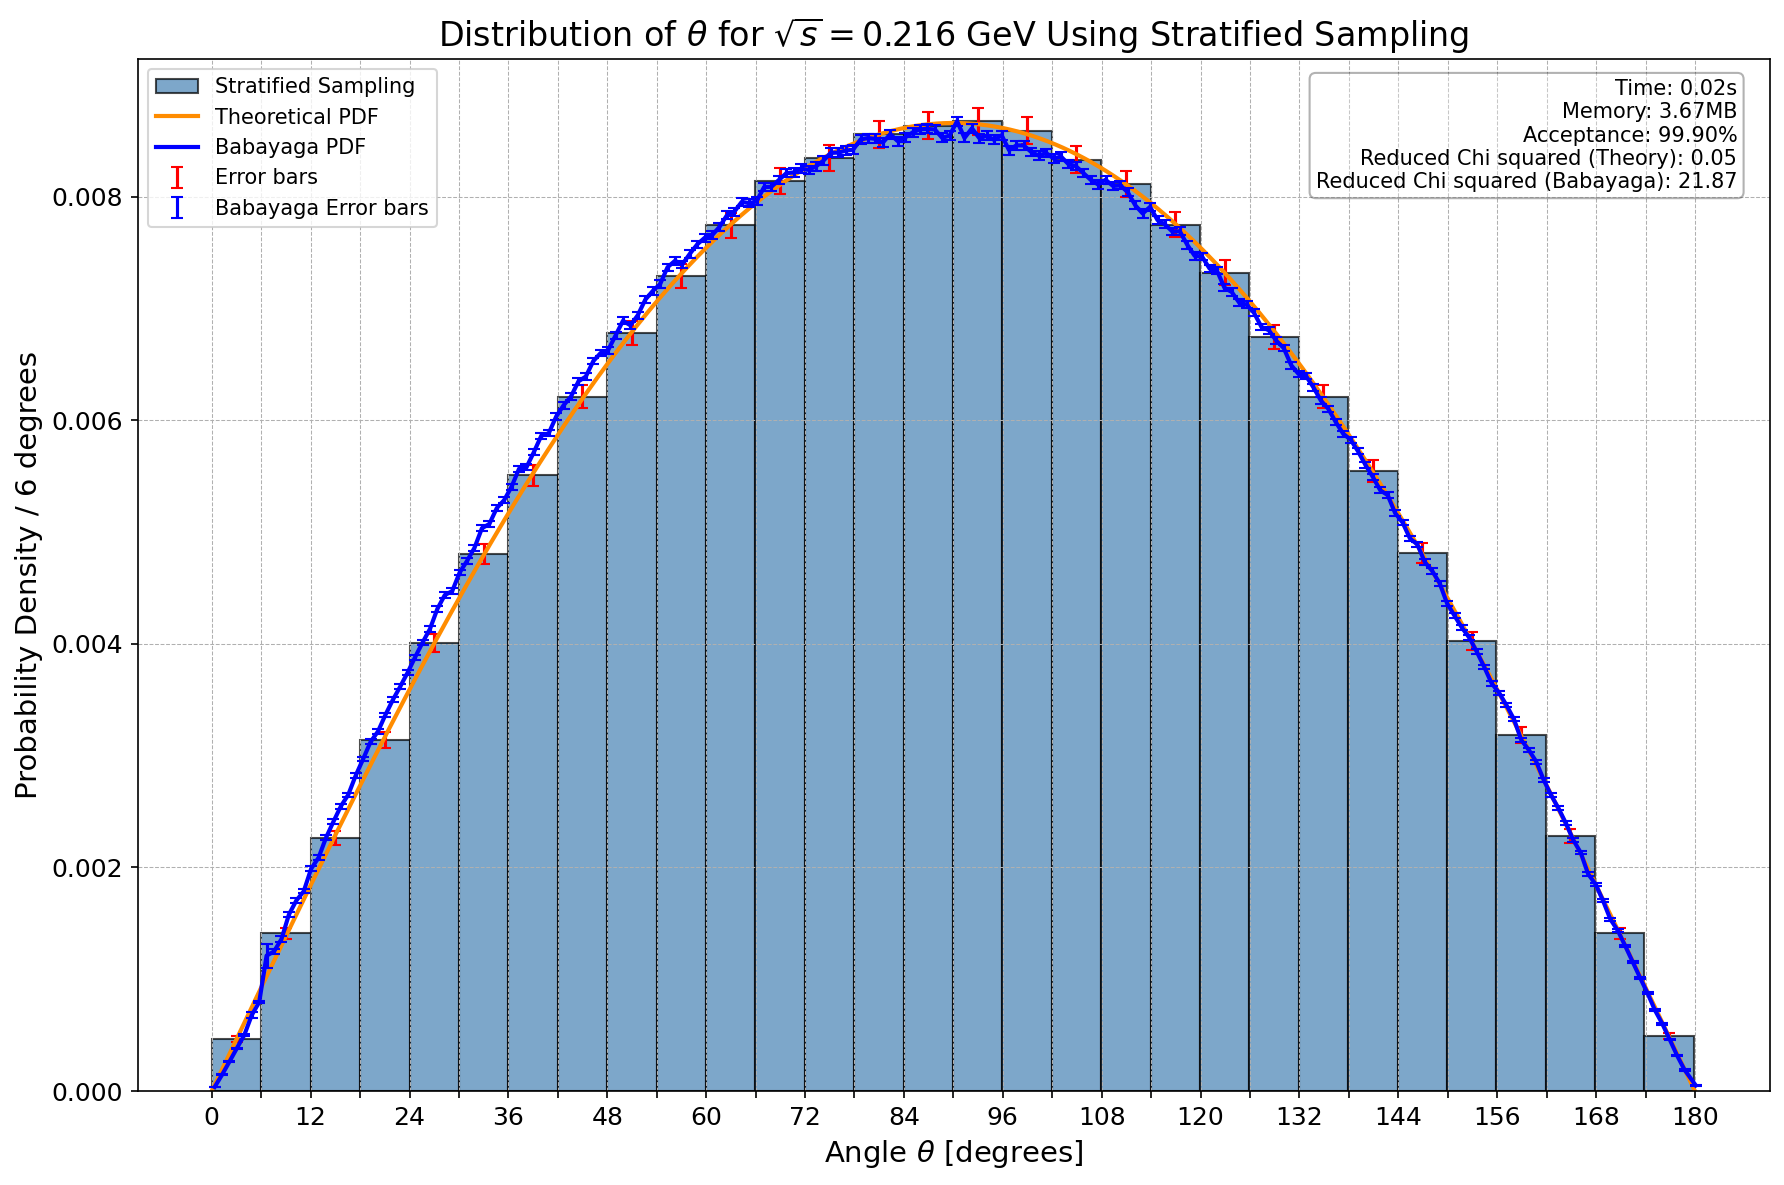

In [50]:
observed_counts, bins = np.histogram(theta_samples_st, bins=30, density=False)
bin_widths = np.diff(bins)

expected_probs = np.array([quad(pdf_norm_wrap, bins[i], bins[i+1])[0] for i in range(len(bins)-1)])
expected_counts = expected_probs / sum(expected_probs) * sum(observed_counts)
chi_squared_stat_t = chisquare(f_obs=observed_counts, f_exp=expected_counts)

degrees_of_freedom_t = len(bins) - 1
reduced_chi_squared_t = chi_squared_stat_t.statistic / degrees_of_freedom_t

expected_counts_b, _ = np.histogram(Babayaga[0], bins=bins, weights=Babayaga[1], density=False)
scaling_factor = observed_counts.sum() / expected_counts_b.sum()
expected_counts_b *= scaling_factor
chi_squared_stat_b = chisquare(f_obs=observed_counts, f_exp=expected_counts_b)

reduced_chi_squared_b = chi_squared_stat_b.statistic / degrees_of_freedom_t

fig, ax = plt.subplots(figsize=(12, 8))

counts, bins, patches = ax.hist(theta_samples_st, bins=30, density=True, color="steelblue", edgecolor='black', alpha=0.7, label='Stratified Sampling')

bin_centers = 0.5 * (bins[1:] + bins[:-1])
bin_width = np.diff(bins)
total_samples = len(theta_samples_st)
errors = np.sqrt(counts / (total_samples * bin_width))
ax.errorbar(bin_centers, counts, yerr=errors, fmt="none", ecolor="r", capsize=3, label="Error bars")

angles = np.linspace(0, 180, 1000)
ax.plot(angles, pdf_norm_wrap(angles), color="darkorange", linewidth=2, label="Theoretical PDF")

k = (np.max(Babayaga[1])) / np.max(counts)
baba_plotted = Babayaga[1] / k
centers = [Babayaga[0][i] + (Babayaga[0][i+1] - Babayaga[0][i]) / 2 for i in np.arange(0, len(Babayaga[0]) - 1)]
centers.append(Babayaga[0][-1] + (Babayaga[0][-1] - Babayaga[0][-2]))
ax.plot(centers, baba_plotted, color="blue", linewidth=2, label="Babayaga PDF")

ax.errorbar(centers, baba_plotted, yerr=Babayaga[2] / k, fmt="none", ecolor="blue", capsize=3, label="Babayaga Error bars")

ax.set_title(r"Distribution of $\theta$ for $\sqrt{s}=$" + str(round(E_sim, 3)) + " GeV Using Stratified Sampling", fontsize=16)
ax.set_xlabel(r"Angle $\theta$ [degrees]", fontsize=14)
ax.set_ylabel("Probability Density / 6 degrees", fontsize=14)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
degrees_x = np.arange(0, 181, 6)
ax.set_xticks(degrees_x)
ax.set_xticklabels([str(degree) if degree % 12 == 0 else '' for degree in degrees_x])
ax.tick_params(axis="both", which="major", labelsize=12)

info_text = (f"Time: {time_st:.2f}s\n"
             f"Memory: {mem_usage_st:.2f}MB\n"
             f"Acceptance: {accepted_st * 100:.2f}%\n"
             f"Reduced Chi squared (Theory): {reduced_chi_squared_t:.2f}\n"
             f"Reduced Chi squared (Babayaga): {reduced_chi_squared_b:.2f}")
ax.text(0.98, 0.98, info_text, transform=ax.transAxes, fontsize=10, verticalalignment="top", horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.3, boxstyle="round,pad=0.3"))

plt.tight_layout()
plt.show()


### Point 5
### Synthetic Dataset

   CoM_AntiMuon_px  CoM_AntiMuon_py  CoM_AntiMuon_pz  CoM_Muon_px  \
0         0.000052        -0.000040         0.023120    -0.000052   
1         0.000165         0.000036         0.023120    -0.000165   
2        -0.000131         0.000090         0.023120     0.000131   
3        -0.000033        -0.000444         0.023116     0.000033   
4        -0.000296        -0.000593         0.023111     0.000296   

   CoM_Muon_py  CoM_Muon_pz  
0     0.000040    -0.023120  
1    -0.000036    -0.023120  
2    -0.000090    -0.023120  
3     0.000444    -0.023116  
4     0.000593    -0.023111  


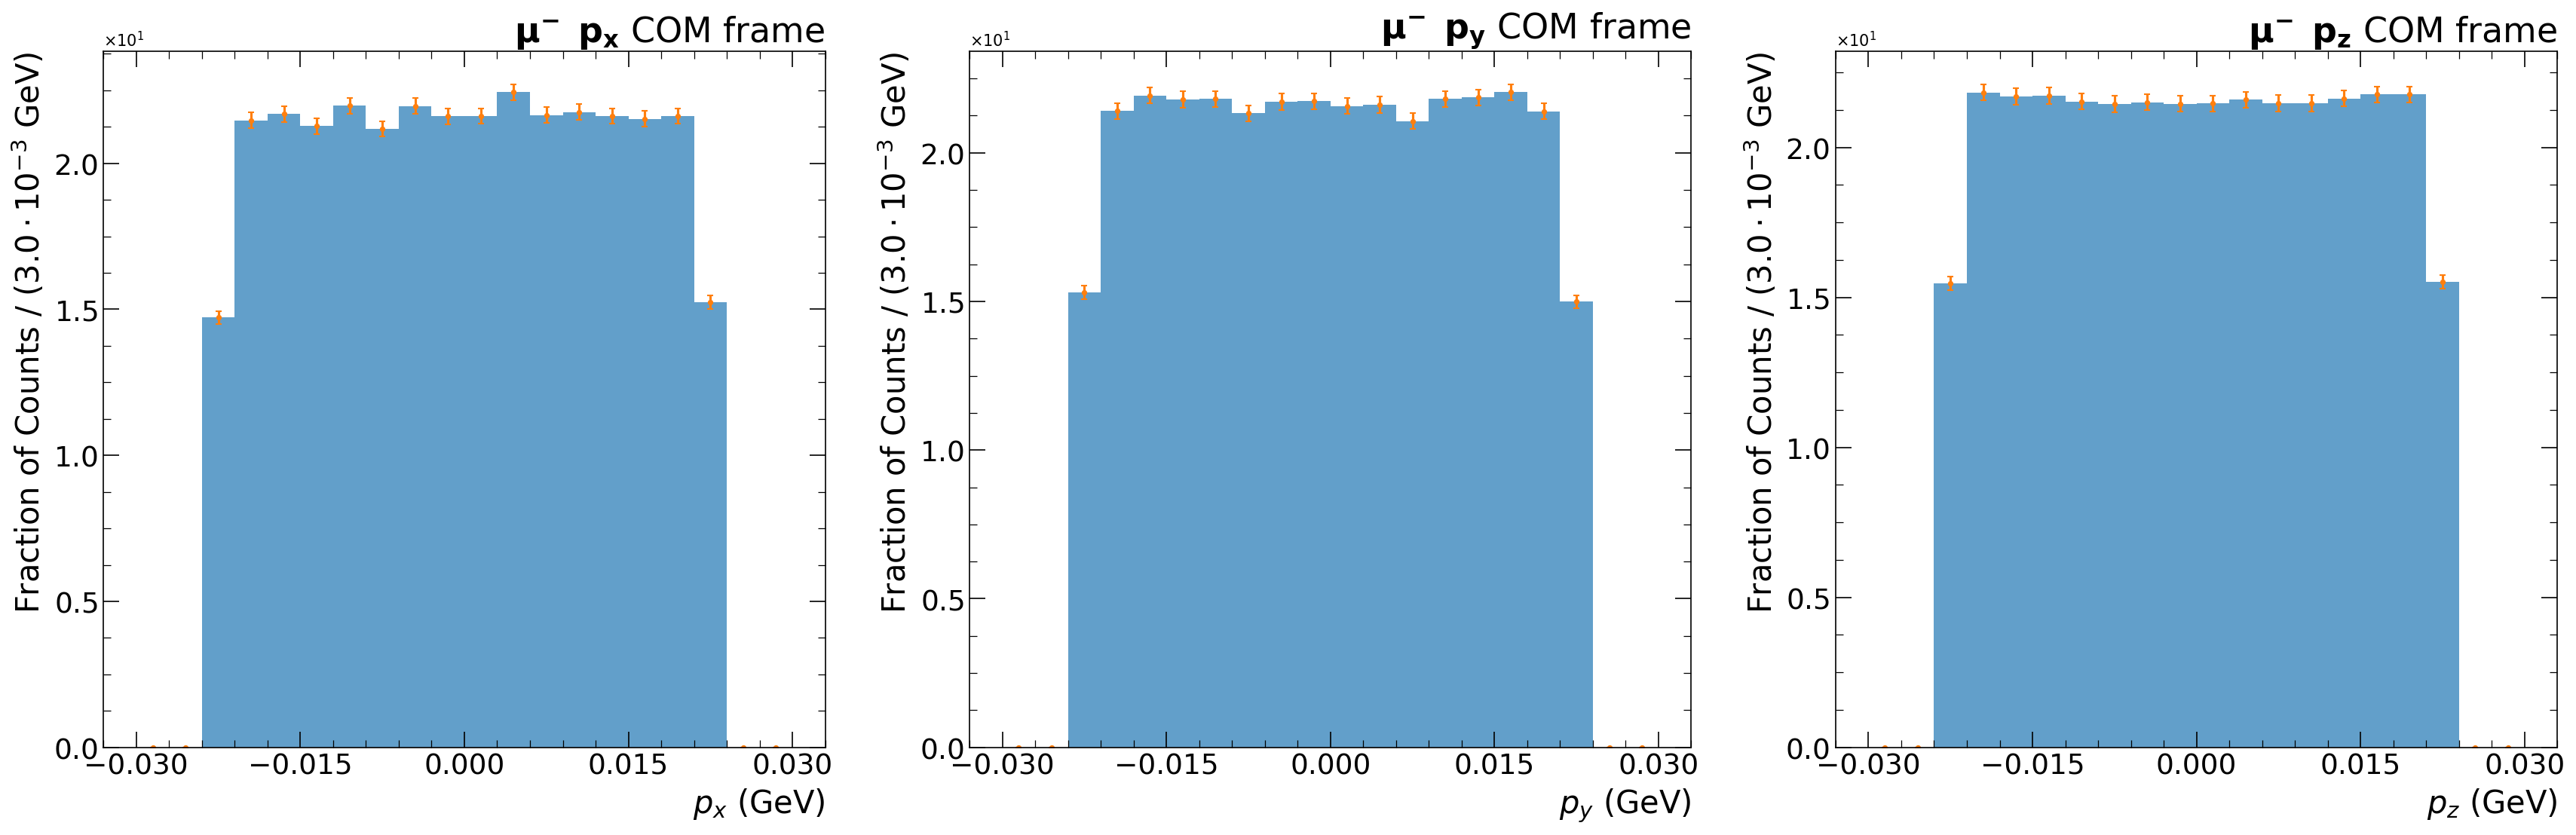

In [73]:
%precision 6

N_samples = len(theta_samples_st)
phi = 360 * np.random.rand(N_samples)
momentum_mu = np.sqrt(E_sim**2 / 4 - mu_mass**2)

sin_theta = np.sin(np.radians(theta_samples_st))
cos_theta = np.cos(np.radians(theta_samples_st))
sin_phi = np.sin(np.radians(phi))
cos_phi = np.cos(np.radians(phi))

momenta = pd.DataFrame({
    "CoM_AntiMuon_px": momentum_mu * cos_phi * sin_theta,
    "CoM_AntiMuon_py": momentum_mu * sin_phi * sin_theta,
    "CoM_AntiMuon_pz": momentum_mu * cos_theta,
})

momenta[["CoM_Muon_px", "CoM_Muon_py", "CoM_Muon_pz"]] = -momenta[["CoM_AntiMuon_px", "CoM_AntiMuon_py", "CoM_AntiMuon_pz"]]
momenta.to_csv("Momenta_CoM.csv", index=False, index_label=False)

components = ["CoM_Muon_px", "CoM_Muon_py", "CoM_Muon_pz"]

fig, axs = plt.subplots(1, 3, figsize=(28, 8))
pl.MuonPlotsCOMPads(axs, momenta,
                 n_maj_loc=5,
                 n_min_loc=5,
                 plot_features=components,
                 alpha=0.7,
                 title_size=22,
                 ylabel_size=20,
                 xlabel_size=20,
                 ticksize_major=18,
                 ticksize_minor=12,
                 legend_size=10,
                 histtype=None,
                 legend=False,
                 plotlabel="Momentum",
                 errlabel="Momentum Error")

print(momenta.head())

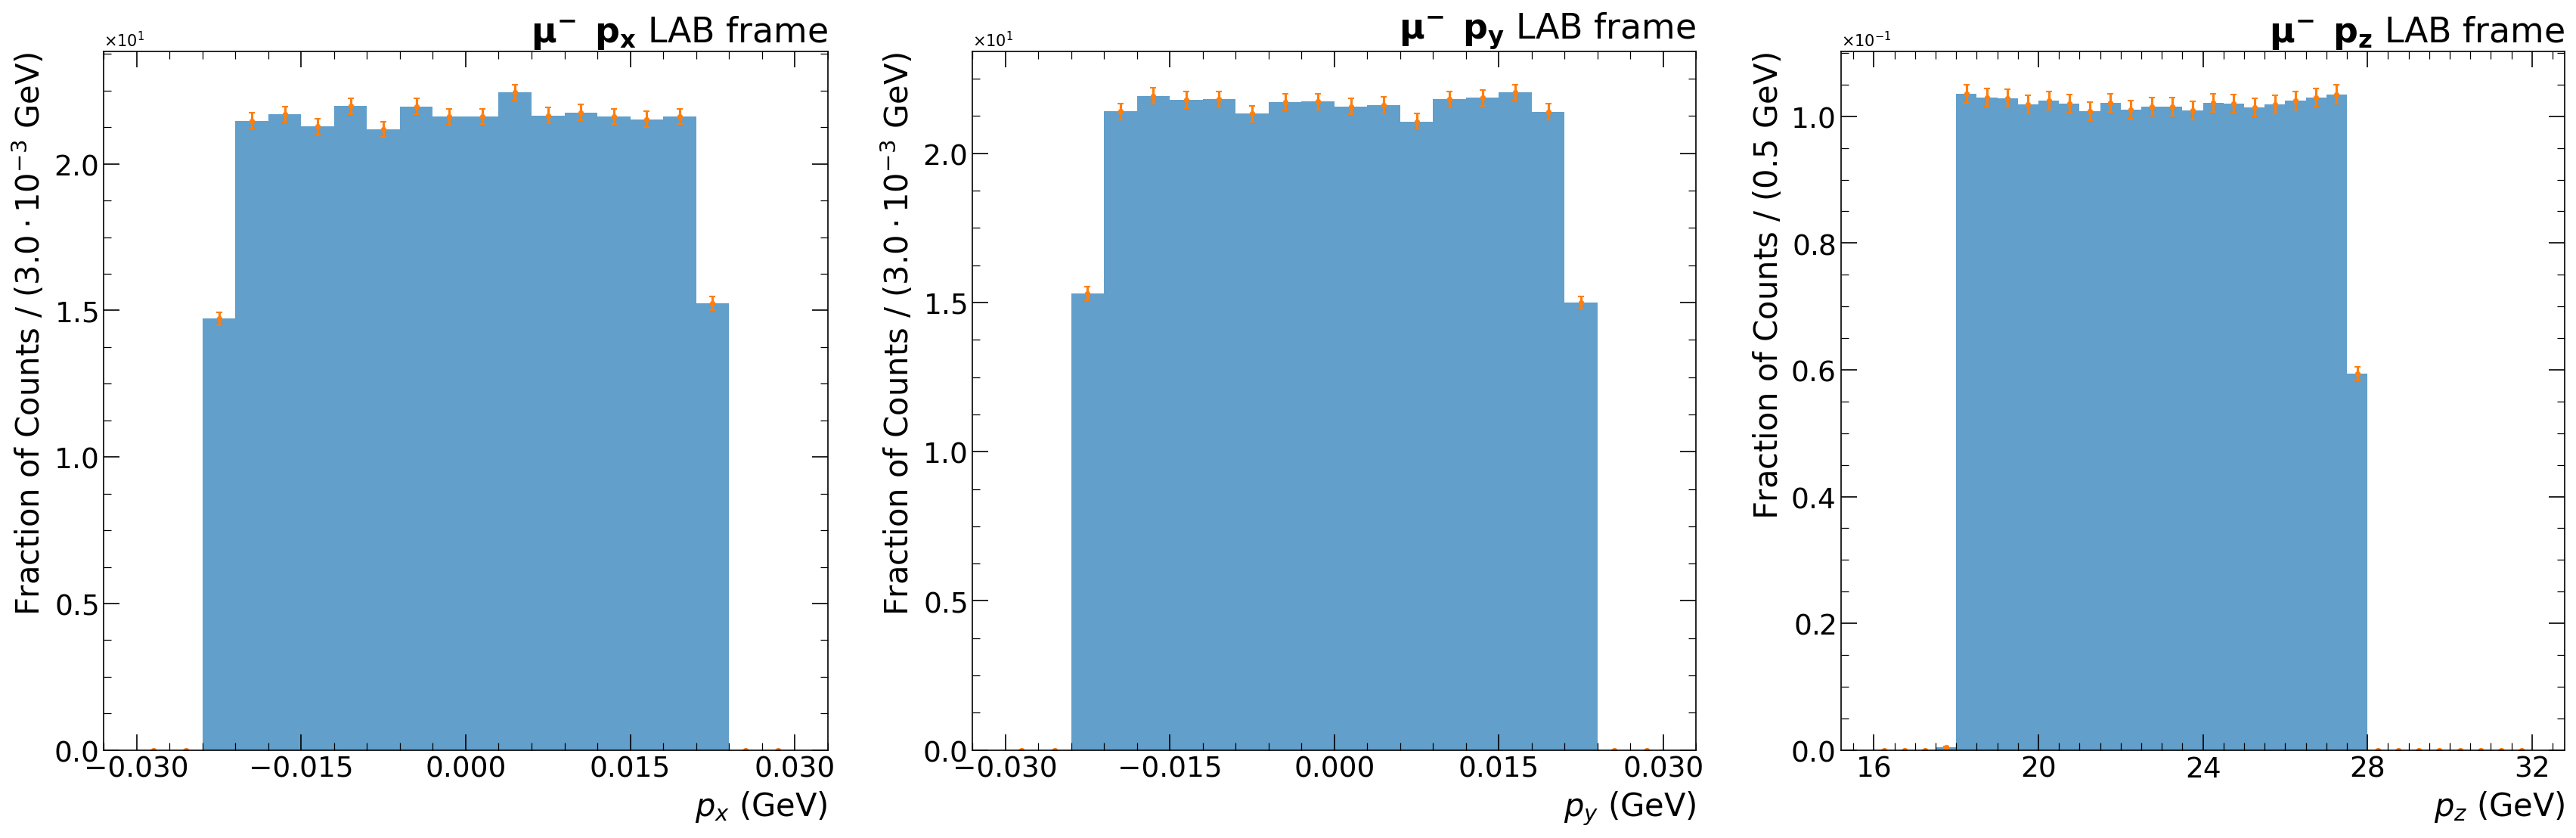

   CoM_AntiMuon_px  CoM_AntiMuon_py  CoM_AntiMuon_pz  CoM_Muon_px  \
0         0.000052        -0.000040         0.023120    -0.000052   
1         0.000165         0.000036         0.023120    -0.000165   
2        -0.000131         0.000090         0.023120     0.000131   
3        -0.000033        -0.000444         0.023116     0.000033   
4        -0.000296        -0.000593         0.023111     0.000296   

   CoM_Muon_py  CoM_Muon_pz  LAB_Muon_E  LAB_Muon_px  LAB_Muon_py  LAB_Muon_pz  
0     0.000040    -0.023120   17.999318    -0.000052     0.000040    17.999008  
1    -0.000036    -0.023120   17.999430    -0.000165    -0.000036    17.999120  
2    -0.000090    -0.023120   17.999414     0.000131    -0.000090    17.999104  
3     0.000444    -0.023116   18.000208     0.000033     0.000444    17.999897  
4     0.000593    -0.023111   18.001308     0.000296     0.000593    18.000998  


In [79]:
boosted_momenta = momenta.apply(lambda row: lorentz_boost(E_sim / 2, row["CoM_Muon_px"], row["CoM_Muon_py"], row["CoM_Muon_pz"], gamma), axis=1)

momenta[["LAB_Muon_E", "LAB_Muon_px", "LAB_Muon_py", "LAB_Muon_pz"]] = pd.DataFrame(boosted_momenta.tolist(), index=momenta.index).iloc[:, :4]

components = ["LAB_Muon_px", "LAB_Muon_py", "LAB_Muon_pz"]
fig, axs = plt.subplots(1, 3, figsize=(28, 8))
pl.MuonPlotsLABPads(axs,
                    momenta, 
                    plot_features=components, 
                    alpha=0.7, 
                    title_size=22, 
                    ylabel_size=20, 
                    xlabel_size=20, 
                    ticksize_major=18, 
                    ticksize_minor=12, 
                    legend_size=10, 
                    histtype=None, 
                    legend=False, 
                    plotlabel="Momentum", 
                    errlabel="Momentum Error")
plt.show()

print(momenta.head())

### Point 6

### Beryllium target and Rescaling factor
Given $N$ generated events, we can calculate the correct statistics for this experiment lasting one week just by applying to the simulated events a rescaling factor. The target is a 3cm thick Beryllium block[8,9] and it is bombarded by a positrons arriving at a rate of $10^6$ Hz.

<div align="center"><img src="./img/block.png" width=600></div>

The number of $(\mu^+ \mu^-)$ pairs produced per positron bunch on target is:

$$N(\mu^+\mu^-) = \sigma(e^+e^- \longrightarrow \mu^+\mu^-)N(e^+)\rho(e^-)D,$$

where $N(e^+)$ is the number of positrons, $\rho(e^-)$ is target electron density and $D$ is the thickness of the Beryllium block.

$$\rho(e^-) = \frac{\rho_{Be}{N_A}}{M_{Be}},$$

where $N_A  $ is Avogadro's number, $M_{Be}$ is molar mass of Beryllium and $\rho_{Be}$ is density of Beryllium.

$$N(e^+) = \omega_{e^+}T$$

where $\omega_{e^+}$  is rate of positron and T is time of the experiment.

In [28]:
N_A = 6.02214076e23 # [1/mol] avogadro constant
dens= 1.848 # [g/cm^3] density of Beryllium
m = 9.012182 # [g/mol] molar mass Beryllium
l = 3 # [cm] thickness of Beryllium block
e=4 #number of electron of Beryllium
rate = 1e6 # [1/s] rate of positron
t=604800 # time of the experiment (seconds in a week)

N_p=rate*t #number of positrons
N= cross_section(s=E_sim**2)*1e-33*rate*t*e*(dens*N_A/m*l) # number of created muons

rescaling_factor = N/N_p

print(" Number of positrons : ","{:.2E}".format(N_p))
print(r' Number of created muons in one week operation at E = ',"{:.3f}".format(E_sim),"GeV"," : ","{:.2E}".format(N))
print(" Rescaling factor: ","{:.2E}".format(rescaling_factor))

 Number of positrons :  6.05E+11
 Number of created muons in one week operation at E =  0.216 GeV  :  5.26E+05
 Rescaling factor:  8.69E-07


### Point 7

### Point 8

### Point 9

### References

[1] [Hit or Miss MonteCarlo](https://www.researchgate.net/figure/The-basic-principle-of-the-Monte-Carlo-hit-and-miss-method_fig6_323557242)

[2] Anderson, E. C. (1999, October 20). Monte Carlo methods and importance sampling. ib.berkeley.edu. https://ib.berkeley.edu/labs/slatkin/eriq/classes/guest_lect/mc_lecture_notes.pdf

[3] Christian P. Robert (2015, April 08). The Metropolis-Hastings algorithm. https://arxiv.org/abs/1504.01896

[4] Sampling from a probability distribution https://cs.brown.edu/courses/cs1951k/lectures/2020/inverse_transform_sampling.pdf

[5] A. Doucet, N. de Freitas, N. Gordon. An Introduction To Sequential MonteCarlo Methods https://www.stats.ox.ac.uk/~doucet/doucet_defreitas_gordon_smcbookintro.pdf

[6] Stratified Sampling, ScienceDirect https://www.sciencedirect.com/topics/mathematics/stratified-sampling)

[7] Relativistic Kinematics of Particle Interactions, W von Schlipp e March 2002 https://web.physics.utah.edu/~jui/5110/hw/kin_rel.pdf

[8] Production of the Smallest QED Atom: True Muonium (𝜇+⁢𝜇−) Stanley J. Brodsky and Richard F. Lebed Phys. Rev. Lett. 102, 213401 – Published 26 May 2009

[9] Muon production and accumulation from positrons on target, M. Boscolo ,1,* M. Antonelli,1 A. Ciarma ,1 and P. Raimondi2 1INFN-LNF, Via E. Fermi 40, 00044 Frascati, Rome, Italy 2ESRF, 71 avenue des Martyrs, 38000 Grenoble, France